In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_excel("/kaggle/input/datasets/kohinrahman/kohinrahman/Air_BNB.xlsx")

In [3]:
data.drop('id', axis=1, inplace=True)

In [4]:
data.head()

,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,Entire home/apt,3,1.0,strict,True,f,100.0,1.0,1.0,5.010635
1,Entire home/apt,7,1.0,strict,True,t,93.0,3.0,3.0,5.129899
2,Entire home/apt,5,1.0,moderate,True,t,92.0,1.0,3.0,4.976734
3,Entire home/apt,4,1.0,flexible,True,f,NaN,2.0,2.0,6.620073
4,Entire home/apt,2,1.0,moderate,True,t,40.0,0.0,1.0,4.744932


In [5]:
cat = []
num = []
bl = []
for column in data.columns:
    if data[column].dtype == 'object':
        cat.append(column)
    elif data[column].dtype == 'bool':
        bl.append(column)
    else:
        num.append(column)

In [6]:
data[num].head()

,accommodates,bathrooms,review_scores_rating,bedrooms,beds,log_price
0,3,1.0,100.0,1.0,1.0,5.010635
1,7,1.0,93.0,3.0,3.0,5.129899
2,5,1.0,92.0,1.0,3.0,4.976734
3,4,1.0,NaN,2.0,2.0,6.620073
4,2,1.0,40.0,0.0,1.0,4.744932


In [12]:
def misaligned_data_treatment(value):
    if value == 'super_strict_30' or value=='super_strict_60':
        return 'strict'
    else:
        return value

In [13]:
data['cancellation_policy'] = data['cancellation_policy'].apply(misaligned_data_treatment)

In [14]:
data['cancellation_policy'].value_counts()

cancellation_policy
strict      32503
flexible    22545
moderate    19063
Name: count, dtype: int64

In [15]:
def outlier_treatment(column):
    q1 = data[column].describe()['25%']
    q3 = data[column].describe()['75%']
    iqr = q3-q1
    ur = q3+ 1.5*iqr
    lr = q1- 1.5*iqr
    return ur,lr

In [16]:
for i in num:
    upr,lwr = outlier_treatment(i)
    print(upr, lwr)
    data[i] = np.where(data[i]>upr,upr,data[i])
    data[i] = np.where(data[i]<lwr,lwr,data[i])

7.0 -1.0
1.0 1.0
112.0 80.0
1.0 1.0
3.5 -0.5
6.574657392391346 2.9631865462232887


<Axes: >

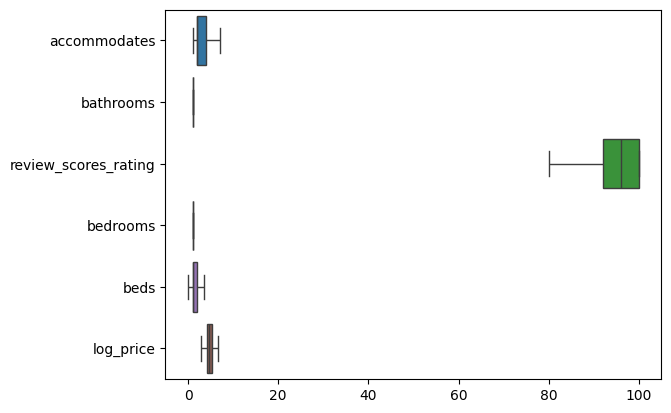

In [17]:
sns.boxplot(data[num],orient = 'h')

In [18]:
cat

['room_type', 'cancellation_policy', 'instant_bookable']

In [19]:
for i in cat:
    print(data[i].value_counts())
    print()

room_type
Entire home/apt    41310
Private room       30638
Shared room         2163
Name: count, dtype: int64

cancellation_policy
strict      32503
flexible    22545
moderate    19063
Name: count, dtype: int64

instant_bookable
f    54660
t    19451
Name: count, dtype: int64



In [20]:
data.head()

,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,Entire home/apt,3.0,1.0,strict,True,f,100.0,1.0,1.0,5.010635
1,Entire home/apt,7.0,1.0,strict,True,t,93.0,1.0,3.0,5.129899
2,Entire home/apt,5.0,1.0,moderate,True,t,92.0,1.0,3.0,4.976734
3,Entire home/apt,4.0,1.0,flexible,True,f,NaN,1.0,2.0,6.574657
4,Entire home/apt,2.0,1.0,moderate,True,t,80.0,1.0,1.0,4.744932


In [21]:
pd.Categorical(data['cancellation_policy'].unique())

['strict', 'moderate', 'flexible']
Categories (3, object): ['flexible', 'moderate', 'strict']

In [22]:
pd.Categorical(data['cancellation_policy'].unique()).codes

array([2, 1, 0], dtype=int8)

In [23]:
data['cancellation_policy'] = pd.Categorical(data['cancellation_policy']).codes

In [24]:
data.head()

,room_type,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price
0,Entire home/apt,3.0,1.0,2,True,f,100.0,1.0,1.0,5.010635
1,Entire home/apt,7.0,1.0,2,True,t,93.0,1.0,3.0,5.129899
2,Entire home/apt,5.0,1.0,1,True,t,92.0,1.0,3.0,4.976734
3,Entire home/apt,4.0,1.0,0,True,f,NaN,1.0,2.0,6.574657
4,Entire home/apt,2.0,1.0,1,True,t,80.0,1.0,1.0,4.744932


In [25]:
data2 = pd.get_dummies(data,columns = ['room_type'])

In [26]:
data2.head()

,accommodates,bathrooms,cancellation_policy,cleaning_fee,instant_bookable,review_scores_rating,bedrooms,beds,log_price,room_type_Entire home/apt,room_type_Private room,room_type_Shared room
0,3.0,1.0,2,True,f,100.0,1.0,1.0,5.010635,True,False,False
1,7.0,1.0,2,True,t,93.0,1.0,3.0,5.129899,True,False,False
2,5.0,1.0,1,True,t,92.0,1.0,3.0,4.976734,True,False,False
3,4.0,1.0,0,True,f,NaN,1.0,2.0,6.574657,True,False,False
4,2.0,1.0,1,True,t,80.0,1.0,1.0,4.744932,True,False,False


In [27]:
data2['instant_bookable'] = pd.Categorical(data['instant_bookable']).codes

In [28]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   accommodates               74111 non-null  float64
 1   bathrooms                  73911 non-null  float64
 2   cancellation_policy        74111 non-null  int8   
 3   cleaning_fee               74111 non-null  bool   
 4   instant_bookable           74111 non-null  int8   
 5   review_scores_rating       57389 non-null  float64
 6   bedrooms                   74020 non-null  float64
 7   beds                       73980 non-null  float64
 8   log_price                  74111 non-null  float64
 9   room_type_Entire home/apt  74111 non-null  bool   
 10  room_type_Private room     74111 non-null  bool   
 11  room_type_Shared room      74111 non-null  bool   
dtypes: bool(4), float64(6), int8(2)
memory usage: 3.8 MB


In [29]:
for i in data2.columns:
    if data2[i].dtype =='bool':
        data2[i] = data2[i].astype('int')

In [30]:
data2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   accommodates               74111 non-null  float64
 1   bathrooms                  73911 non-null  float64
 2   cancellation_policy        74111 non-null  int8   
 3   cleaning_fee               74111 non-null  int64  
 4   instant_bookable           74111 non-null  int8   
 5   review_scores_rating       57389 non-null  float64
 6   bedrooms                   74020 non-null  float64
 7   beds                       73980 non-null  float64
 8   log_price                  74111 non-null  float64
 9   room_type_Entire home/apt  74111 non-null  int64  
 10  room_type_Private room     74111 non-null  int64  
 11  room_type_Shared room      74111 non-null  int64  
dtypes: float64(6), int64(4), int8(2)
memory usage: 5.8 MB
